## Table of Contents:
* [1. For the motif-centric tools, how similar are initial TFBS regions?](#first-bullet)
    * [1.1 What if we match on PWM p-val?](#first1-bullet)
* [2. How many region-PWM pairs overlap (upset plots)](#second-bullet)
* [3. How similar are scoring systems?](#third-bullet)
    * [3.1 TOBIAS bound threshold](#third1-bullet)
    * [3.2 Jaccard of threshold pairs](#third2-bullet) 
* [4. Genome-wide trends](#fourth-bullet)
* [5. Global TF ranking similarity](#fifth-bullet)

In [68]:
import pybedtools, os, re, pickle
import pandas as pd
import numpy as np

from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D  

from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.lines as lines
from scipy.cluster import hierarchy
from scipy.stats import pearsonr

from upsetplot import UpSet, plot
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) #for upset plot
from matplotlib_venn import venn2


from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.metrics import mean_squared_error
from itertools import combinations, product

In [69]:
sns.set(style='whitegrid', rc={"figure.dpi":100, 'savefig.dpi':300})  
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = ['Arial', 'sans-serif']

color_scheme_cl = {"GM12878": "#267A9E", "MCF7": "#51A885", "K562":"#F5A936", "SKNSH": "#DB7476", "HEPG2": "#986B9B"}
color_scheme_prog = {"tobias":"#008080", "hint":"#CC5500", "print": "#A4254E"}
color_scheme_st = {"peakreads":"green", "cells":"#CE3B59", "frip":"#F5C23C", "reads":"#993CBE", "baseline":"black"}

# 1. For the motif-centric tools, how similar are initial TFBS regions? <a class="anchor" id="first-bullet"></a>

In [70]:
def _get_cellline_arrays(cl):
    peak_file = f"../03_peakcalls/{cl}_filt_500bp.exclusion.bed.gz"
    df = pd.read_csv(f"{peak_file}", header=None, sep="\t")
    df["region_atac"] = df[0].astype(str) + ":" + df[1].astype(str) + "-" + df[2].astype(str)
    all_atac_regions = df["region_atac"].tolist()
    
    infile="../05_footprinting/program_input_files/jaspar2022_motifs_to_clusters.txt.gz"
    TF_df = pd.read_csv(infile, sep=" ", header=None, usecols = [0], names=["motif"])
    TF_df["motif"] = [i.upper() for i in TF_df["motif"]] 
    all_tfs = TF_df["motif"].tolist()
    return all_atac_regions, all_tfs
    
    
def _standardize(cl, tool, region_array, pwm_array):
    #new users will need to create this input
    core_dir = "../../06_dataquality/"
    df = pd.read_csv(f"{core_dir}/{tool}/cleaned/{cl}-cellFilt.bed.gz", sep="\t", index_col=0)

    df2 = df.pivot_table(index="region_atac", columns="motif", aggfunc='size', fill_value=0)
    df2 = df2.reindex(pwm_array, axis=1, fill_value=0)
    df2 = df2.reindex(region_array, axis=0, fill_value=0)
    if df.shape[0] == df2.sum().sum():
        return df2
    else: 
        print("ERROR")
        return

In [71]:
res_dict = {}

for cl in ["HEPG2", "K562", "SKNSH", "MCF7"]:
    #print(cl)
    
    #get indexes to pivot dataframes on, build them, and quality check
    region_array, pwm_array = _get_cellline_arrays(cl)
    tobias_mat = _standardize(cl, "tobias", region_array, pwm_array)
    print_mat = _standardize(cl, "print", region_array, pwm_array)

    if not (tobias_mat.index.equals(print_mat.index)) and (tobias_mat.columns.equals(print_mat.columns)):
        print("ERROR")
    
    #flatten into 2 column df, remove all zero rows, 
    data = {'TOBIAS': tobias_mat.to_numpy().flatten(),
            'PRINT': print_mat.to_numpy().flatten()
           }
    df = pd.DataFrame(data)
    df_nonZero = df.loc[~(df==0).all(axis=1)].copy()

    df_nonZero.loc[:, 'common'] = df_nonZero.min(axis=1) #make column of common sites.
    df_nonZero["TOBIAS"] = df_nonZero["TOBIAS"]- df_nonZero['common'] #remove common values from each
    df_nonZero["PRINT"] = df_nonZero["PRINT"]- df_nonZero['common']
    
    upset_data = pd.Series(
        [df_nonZero["common"].sum(), df_nonZero["TOBIAS"].sum(), df_nonZero["PRINT"].sum()],
        index=pd.MultiIndex.from_tuples(
            [(True, True),
             (True, False),
             (False, True),
            ],
            names=['TOBIAS', 'PRINT']
        ),
        name='value'
        )
    
    res_dict[cl] = upset_data

print("done")

done


In [72]:
q = []
for k, df in res_dict.items():
    val = (df[True,True]/df.sum())*100
    q.append(val)
    print(f"{k} percent overlap: {val:.2f}%")

print(f"Average percent overlap: {np.mean(q):.2f}%")

# not much different by cell line, just plot mean/sd. 

HEPG2 percent overlap: 34.10%
K562 percent overlap: 34.31%
SKNSH percent overlap: 34.04%
MCF7 percent overlap: 34.95%
Average percent overlap: 34.35%


In [73]:
df_all = pd.concat(res_dict, axis=1)
a = df_all.loc[[ (True, True), (True, False) ]].sum(axis=0).values # .sum().agg(['mean', 'std'], axis=1)
b = df_all.loc[[ (True, True), (False, True) ]].sum(axis=0).values

sum_df = pd.DataFrame.from_dict({"tobias": [np.mean(a), np.std(a)], "print":[np.mean(b), np.std(b)]}, 
                                orient='index',
                                columns=["mean","sd"])
sum_df = sum_df.sort_values(by='mean', ascending=False).reset_index()
display(sum_df)


df_all["mean"] = df_all.mean(axis=1)
df_all["std"] = df_all.std(axis=1)
display(df_all)

,index,mean,sd
0,tobias,50255766.50,4.235554e+06
1,print,18991268.25,1.426984e+06


HEPG2      K562     SKNSH      MCF7         mean  \
TOBIAS PRINT                                                        
True   True   17593965  19754743  17560433  15882593  17697933.50   
       False  32791339  36449424  32647081  28343488  32557833.00   
False  True    1214539   1366736   1372989   1219075   1293334.75   

                       std  
TOBIAS PRINT                
True   True   1.374376e+06  
       False  2.870874e+06  
False  True   7.657647e+04

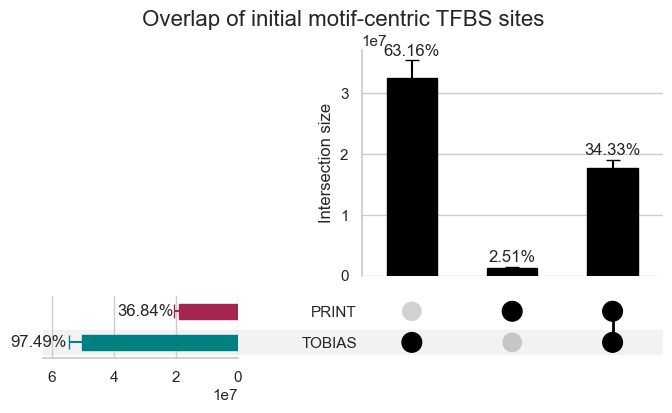

In [74]:
fig = plt.figure(figsize=(8, 4))

upset = UpSet(df_all["mean"], 
              show_percentages="{:.2%}",
             element_size=None)
upset.style_categories("TOBIAS", bar_facecolor=color_scheme_prog["tobias"])
upset.style_categories("PRINT", bar_facecolor=color_scheme_prog["print"])
axes_dict = upset.plot(fig=fig)

#get bar chart x axis,
#add std bars
#move up percentages out of the way. 
bar_ax = axes_dict["intersections"]  # Get bar chart axis
bars = bar_ax.patches 
positions = [bar.get_x() + bar.get_width() / 2 for bar in bars]
heights = [bar.get_height() for bar in bars]
std_values = df_all.set_index("mean").loc[heights]["std"]
bar_ax.errorbar(positions, heights, yerr=std_values, fmt='none', ecolor='black', capsize=5, linewidth=1.5)
annotations = [text for text in bar_ax.texts]
for i, up in zip(annotations, std_values):
    i.set_y(i.get_position()[1] + up)
    
    
# get side bar chart x axis,
# add std bars
# move up percentages out of the way.
bar_ax = axes_dict["totals"] 
bar_ax.set_xlim(sum_df.loc[0]["mean"] + sum_df.loc[0]["sd"]*3, 0)
annotations = [text for text in bar_ax.texts]
for rect, anno in zip(bar_ax.patches, annotations):
    v = anno.get_position()
    newx, newsd, name = sum_df.loc[v[1]][["mean","sd","index"]]

    bar_ax.errorbar(rect.get_width(), v[1], xerr=newsd, 
                    fmt='none', ecolor=color_scheme_prog[name], 
                    capsize=5, linewidth=1.5)
    anno.set_x(newx+newsd*1.2)
    
    
plt.suptitle("Overlap of initial motif-centric TFBS sites", fontsize=16)
plt.show()

TOBIAS  PRINT
True    True     15882593
        False    28343488
False   True      1219075
Name: value, dtype: int64

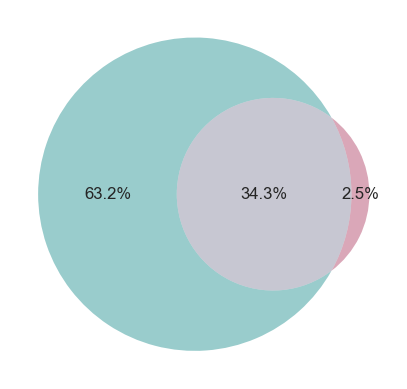

In [75]:
df = res_dict[cl]
display(df)
venn2(subsets = (df_all.loc[(True,False)]["mean"], 
                 df_all.loc[(False,True)]["mean"],
                 df_all.loc[(True,True)]["mean"]), 
      #set_labels = ('TOBIAS', 'PRINT'),
      set_labels = None,
      set_colors=(color_scheme_prog["tobias"], color_scheme_prog["print"]),
      subset_label_formatter=lambda x: f"{(x/df_all['mean'].sum())*100:.1f}%")

plt.show()

## 1.1 What if we match on PWM p-val? <a class="anchor" id="first1-bullet"></a>

In [76]:
def _standardize(file, region_array, pwm_array):
    df = pd.read_csv(file, sep="\t", index_col=0)

    df2 = df.pivot_table(index="region_atac", columns="motif", aggfunc='size', fill_value=0)
    df2 = df2.reindex(pwm_array, axis=1, fill_value=0)
    df2 = df2.reindex(region_array, axis=0, fill_value=0)
    if df.shape[0] == df2.sum().sum():
        return df2
    else: 
        print("ERROR")
        return

res_dict = {}

for cl in ["HEPG2", "K562"]:
    #get indexes to pivot dataframes on, build them, and quality check
    region_array, pwm_array = _get_cellline_arrays(cl)
    
    #tobias
    f = f"../../08_acrosstools/pwm_match_pval/{cl}-cellFilt.bed.gz"
    tobias_mat = _standardize(f, region_array, pwm_array)
    f = f"../../06_dataquality/print/cleaned/{cl}-cellFilt.bed.gz"
    print_mat = _standardize(f, region_array, pwm_array)

    if not (tobias_mat.index.equals(print_mat.index)) and (tobias_mat.columns.equals(print_mat.columns)):
        print("ERROR")
    
    #flatten into 2 column df, remove all zero rows, 
    data = {'TOBIAS': tobias_mat.to_numpy().flatten(),
            'PRINT': print_mat.to_numpy().flatten()
           }
    df = pd.DataFrame(data)
    df_nonZero = df.loc[~(df==0).all(axis=1)].copy()

    df_nonZero.loc[:, 'common'] = df_nonZero.min(axis=1) #make column of common sites.
    df_nonZero["TOBIAS"] = df_nonZero["TOBIAS"]- df_nonZero['common'] #remove common values from each
    df_nonZero["PRINT"] = df_nonZero["PRINT"]- df_nonZero['common']
    
    upset_data = pd.Series(
        [df_nonZero["common"].sum(), df_nonZero["TOBIAS"].sum(), df_nonZero["PRINT"].sum()],
        index=pd.MultiIndex.from_tuples(
            [(True, True),
             (True, False),
             (False, True),
            ],
            names=['TOBIAS', 'PRINT']
        ),
        name='value'
        )
    
    res_dict[cl] = upset_data

print("done")

done


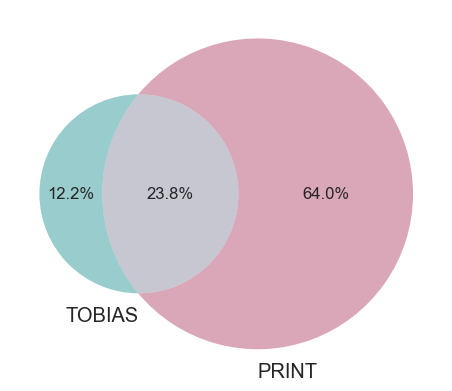

In [77]:
df_all = pd.concat([res_dict["HEPG2"], 
           res_dict["K562"]], axis=1)

df_all.columns = ["HEPG2", "K562"]
df_all["mean"] = df_all.mean(axis=1)
df_all["std"] = df_all.std(axis=1)
venn2(subsets = (df_all.loc[(True,False)]["mean"], 
                 df_all.loc[(False,True)]["mean"],
                 df_all.loc[(True,True)]["mean"]), 
      set_labels = ('TOBIAS', 'PRINT'),
      #set_labels = None,
      set_colors=(color_scheme_prog["tobias"], color_scheme_prog["print"]),
      subset_label_formatter=lambda x: f"{(x/df_all['mean'].sum())*100:.1f}%")
plt.show()

# 2. How many region-PWM pairs overlap <a class="anchor" id="second-bullet"></a>

In [78]:
def BuildUpsetData(df_nonZero):
    
    df = df_nonZero.copy()
    cols = df.columns.tolist()
    if len(cols) != 3:
        print("ERROR; can only handle 3"); return
    
    i = cols[0]
    j = cols[1]
    k = cols[2]
    
    #calculate those in common and then remove them. 
    df.loc[:, 'common'] = df.min(axis=1)
    df[i] = df[i]- df['common']
    df[j] = df[j]- df['common']
    df[k] = df[k]- df['common']
    
    #calculate the overlaps between them
    df.loc[:, f'{i}:{j}'] = np.where((df[i] != 0) & (df[j] != 0) & (df[k] ==0), df[[i, j]].min(axis=1), 0)
    df.loc[:, f'{i}:{k}'] = np.where((df[i] != 0) & (df[k] != 0) & (df[j] ==0), df[[i, k]].min(axis=1), 0)
    df.loc[:, f'{j}:{k}'] = np.where((df[j] != 0) & (df[k] != 0) & (df[i] ==0), df[[j, k]].min(axis=1), 0)

    #remove the ones above and the resulting entries are unique. 
    df[i] = df[i] - df[f'{i}:{j}'] - df[f'{i}:{k}']
    df[j] = df[j] - df[f'{i}:{j}'] - df[f'{j}:{k}']
    df[k] = df[k] - df[f'{i}:{k}'] - df[f'{j}:{k}']

    #check if they overlap. 
    o_total = df_nonZero.sum().sum()
    n_total = df[[i, j, k]].sum().sum() + \
        np.sum(df["common"]*3) + \
        np.sum(df[f"{i}:{j}"]*2) + \
        np.sum(df[f"{i}:{k}"] *2) + \
        np.sum(df[f"{j}:{k}"] *2)
    
    if o_total != n_total:
        print(f"Error: something went wrong, totals don't match o:{o_total}, n:{n_total}"); return 
    
    return df


def reformat(data):
    df = pd.DataFrame(data)
    df_nonZero = df.loc[~(df==0).all(axis=1)]
    data_sep = BuildUpsetData(df_nonZero)
    return data_sep


def check_identical(df1,df2,df3):
    val =  (df1.index.equals(df2.index)) and \
           (df1.index.equals(df3.index)) and \
           (df1.columns.equals(df2.columns)) and \
           (df1.columns.equals(df3.columns))
    return val
        

res = {}
core_dir = "../../06_dataquality/"

for cl in ["HEPG2", "K562", "MCF7", "SKNSH"]:
    #print(cl)
    hint_df =   pd.read_csv(f"{core_dir}/hint/mats/{cl}-cellFilt.mat", index_col=0)
    tobias_df = pd.read_csv(f"{core_dir}/tobias/mats/bound_threshold/{cl}-cellFilt.mat", index_col=0)
    print_df =  pd.read_csv(f"{core_dir}/print/mats/thresh_03/{cl}-cellFilt.mat", index_col=0)
    
    if not check_identical(hint_df, tobias_df, print_df):
        print("ERROR"); break
    
    #all peaks
    data = {
    'HINT': hint_df.to_numpy().flatten(),
    'TOBIAS': tobias_df.to_numpy().flatten(),
    'PRINT': print_df.to_numpy().flatten()
    }
    res[f"{cl}:allpeaks"] = reformat(data)
     
    #peaks above a threshold
    peak_df = pd.read_csv(f"{core_dir}/tfbs_universe/PeakCoverage_{cl}.csv.gz", index_col=0)
    keep_peaks = peak_df[peak_df[cl] >= 100].index
    data = {
    'HINT': hint_df.loc[keep_peaks].to_numpy().flatten(),
    'TOBIAS': tobias_df.loc[keep_peaks].to_numpy().flatten(),
    'PRINT': print_df.loc[keep_peaks].to_numpy().flatten()
    }
    res[f"{cl}:subpeaks"] = reformat(data)
    
    #TF-agnosic
    data = {
    'HINT': hint_df.sum(axis=1).to_numpy().flatten(),
    'TOBIAS': tobias_df.sum(axis=1).to_numpy().flatten(),
    'PRINT': print_df.sum(axis=1).to_numpy().flatten()
    }
    res[f"{cl}:tf-agnostic"] = reformat(data)
    
    
print(res.keys())

dict_keys(['HEPG2:allpeaks', 'HEPG2:subpeaks', 'HEPG2:tf-agnostic', 'K562:allpeaks', 'K562:subpeaks', 'K562:tf-agnostic', 'MCF7:allpeaks', 'MCF7:subpeaks', 'MCF7:tf-agnostic', 'SKNSH:allpeaks', 'SKNSH:subpeaks', 'SKNSH:tf-agnostic'])


In [79]:
overlaps = {}
for k, data_sep in res.items():
    val = (data_sep["common"].sum()/data_sep.sum().sum())*100
    overlaps[k] = val
    print(f"{k}:{val}")
    
for cond in ["allpeaks", "subpeaks", "tf-agnostic"]:
    tmp = np.array([overlaps[k] for k in overlaps if cond in k])
    print(f"{cond}: {round(tmp.mean(),2)}, {round(tmp.std(), 2)}")

HEPG2:allpeaks:3.4562334188864328
HEPG2:subpeaks:4.002131802844424
HEPG2:tf-agnostic:8.48629034132802
K562:allpeaks:3.624389305842299
K562:subpeaks:4.043906909246607
K562:tf-agnostic:8.713687641501387
MCF7:allpeaks:3.493362939514776
MCF7:subpeaks:4.232329037623487
MCF7:tf-agnostic:8.555088863447589
SKNSH:allpeaks:3.3623338013835555
SKNSH:subpeaks:3.3629017692044636
SKNSH:tf-agnostic:8.363076641789661
allpeaks: 3.48, 0.09
subpeaks: 3.91, 0.33
tf-agnostic: 8.53, 0.13


In [80]:
def reformatDF(df):
    upset_data = pd.Series(
        [df["common"].sum(), 
         df["HINT"].sum(), df["TOBIAS"].sum(), df["PRINT"].sum(), 
         df["HINT:TOBIAS"].sum(), df["HINT:PRINT"].sum(), df["TOBIAS:PRINT"].sum()],
        index=pd.MultiIndex.from_tuples(
            [
                (True, True, True),
                (True, False, False),
                (False, True, False),
                (False, False, True),
                (True, True, False),
                (True, False, True),
                (False, True, True),  
            ],
            names=['HINT', 'TOBIAS', 'PRINT']
        ),
        name='value'
    )
    return upset_data
    

#upset data main data. 
df_all = pd.DataFrame([reformatDF(res["HEPG2:allpeaks"]), 
                       reformatDF(res["K562:allpeaks"]),
                       reformatDF(res["MCF7:allpeaks"]),
                       reformatDF(res["SKNSH:allpeaks"])]).T

df_all.columns = ["HEPG2", "K562", "MCF7", "SKNSH"]
df_all["mean"] = df_all.mean(axis=1)
df_all["std"] = df_all.std(axis=1)
display(df_all)

#upset data side data
tmp = {}
for cl in df_all.index.names:
    l = df_all[df_all.index.get_level_values(cl) == True].sum()
    tmp[cl.lower()] = [round(l.loc[["HEPG2", "K562", "MCF7", "SKNSH"]].mean()),
               round(l.loc[["HEPG2", "K562", "MCF7", "SKNSH"]].std())]
sum_df = pd.DataFrame.from_dict(tmp).T
sum_df.columns = ["mean", "sd"]
sum_df = sum_df.sort_values(by='mean', ascending=False).reset_index()
display(sum_df)

HEPG2     K562     MCF7    SKNSH        mean  \
HINT  TOBIAS PRINT                                                   
True  True   True    544130   593880   545606   528960   553144.00   
      False  False  4957573  5247723  3972361  4996738  4793598.75   
False True   False  3402968  3823427  3526100  4360699  3778298.50   
      False  True   3666984  3471904  4116069  2887960  3535729.25   
True  True   False   480679   511997   422138   506284   480274.50   
      False  True   1056049   947091  1160437   806534   992527.75   
False True   True   1635056  1789635  1875649  1644755  1736273.75   

                              std  
HINT  TOBIAS PRINT                 
True  True   True    24404.718765  
      False  False  487035.262075  
False True   False  369358.901187  
      False  True   440936.701413  
True  True   False   35576.773845  
      False  True   131231.321268  
False True   True   101110.827599

,index,mean,sd
0,hint,6819545,515344
1,print,6817675,749092
2,tobias,6547991,423959


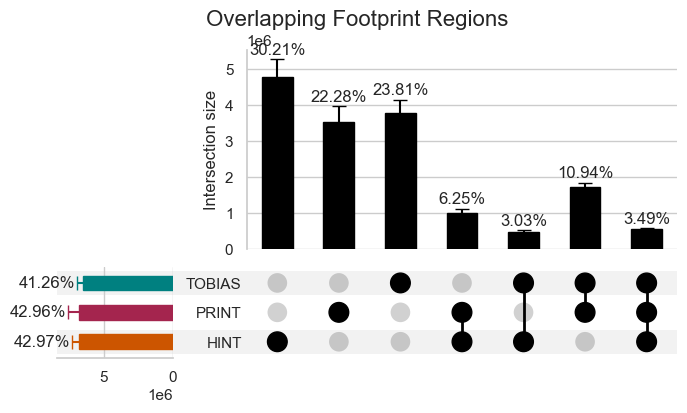

In [81]:
fig = plt.figure(figsize=(8, 4))

upset = UpSet(df_all["mean"], 
              show_percentages="{:.2%}",
             element_size=None)
             #subset_size="sum", show_counts=True)
upset.style_categories("HINT", bar_facecolor=color_scheme_prog["hint"])
upset.style_categories("TOBIAS", bar_facecolor=color_scheme_prog["tobias"])
upset.style_categories("PRINT", bar_facecolor=color_scheme_prog["print"])
axes_dict = upset.plot(fig=fig)

#get bar chart x axis,
#add std bars
#move up percentages out of the way. 
bar_ax = axes_dict["intersections"]  # Get bar chart axis
bars = bar_ax.patches 
positions = [bar.get_x() + bar.get_width() / 2 for bar in bars]
heights = [bar.get_height() for bar in bars]
std_values = df_all.set_index("mean").loc[heights]["std"]
bar_ax.errorbar(positions, heights, yerr=std_values, fmt='none', ecolor='black', capsize=5, linewidth=1.5)
annotations = [text for text in bar_ax.texts]
for i, up in zip(annotations, std_values):
    i.set_y(i.get_position()[1] + up)
    
    
#get side bar chart x axis,
#add std bars
#move up percentages out of the way.
bar_ax = axes_dict["totals"] 
bar_ax.set_xlim(sum_df.loc[0]["mean"] + sum_df.loc[0]["sd"]*3, 0)
annotations = [text for text in bar_ax.texts]
for rect, anno in zip(bar_ax.patches, annotations):
    v = anno.get_position()
    newx, newsd, name = sum_df.loc[v[1]][["mean","sd","index"]]

    bar_ax.errorbar(rect.get_width(), v[1], xerr=newsd, 
                    fmt='none', ecolor=color_scheme_prog[name], 
                    capsize=5, linewidth=1.5)
    anno.set_x(newx+newsd*1.2)

plt.suptitle("Overlapping Footprint Regions", fontsize=16)
plt.show()

# 2. How similar are scoring systems? <a class="anchor" id="third-bullet"></a>

## 2.1 TOBIAS bound threshold <a class="anchor" id="third1-bullet"></a>

In [82]:
infile="../08_acrosstools/tobias_thresholds.txt.gz"
thresh_file = pd.read_csv(infile, sep=" ", header=None, names=["file", "threshold"])

In [83]:
##### FORMAT STANDARD FILES #####
normal = thresh_file.loc[~thresh_file.file.str.contains("combo|cellFilt", regex=True)].copy()
normal[["cell_line", "tmp", "seed"]] = normal.file.str.split('_', expand=True)
normal["group"] = [s[:1] for s in normal["tmp"]]
normal["value"] = [s[1:] for s in normal["tmp"]]
normal.loc[normal.group == "f", "value"] = [f"0.{i[1:]}" for i in normal.loc[normal.group == "f"]["value"]]
normal = normal[["cell_line", "value","group", "threshold"]]
normal[["value"]] = normal[["value"]].apply(pd.to_numeric)
normal["type"] = "normal"
#display(normal)

In [84]:
##### FORMAT BASELINE  #####
baseline = thresh_file.loc[thresh_file.file.str.contains("cellFilt")].copy()
baseline[["cell_line", "tmp"]] = baseline.file.str.split('-', expand=True)


baseline_info = pd.read_csv("../04_downsampling/sampling_stats.csv", sep=",", index_col=0)
baseline_info = baseline_info[baseline_info.sampling_type == "baseline"]
baseline_info["cell_line"] = [re.sub(".summary.txt" , "", x) for x in baseline_info.cell_line]
baseline_info[["file"]] = "baseline"

tmp = baseline_info[["cell_line", "Ncells"]].copy()
tmp.columns = ["cell_line", "value"]; tmp[["group"]] = "c"
add1 = baseline[["cell_line", "threshold"]].merge(tmp, on="cell_line", how="left")

tmp = baseline_info[["cell_line", "Nreadpairs"]].copy()
tmp.columns = ["cell_line", "value"]; tmp[["group"]] = "r"
add2 = baseline[["cell_line", "threshold"]].merge(tmp, on="cell_line", how="left")

tmp = baseline_info[["cell_line", "FRIP"]].copy()
tmp.columns = ["cell_line", "value"]; tmp[["group"]] = "f"
add3 = baseline[["cell_line", "threshold"]].merge(tmp, on="cell_line", how="left")

baseline = pd.concat([add1,add2, add3])
baseline[["value"]] = baseline[["value"]].apply(pd.to_numeric)
baseline["type"] = "baseline"
#display(baseline)

In [85]:
##### FORMAT COMBOS  #####
combos = thresh_file.loc[thresh_file.file.str.contains("combo")].copy()
combos["ComboID"] = combos.file.str.split('_', expand=True)[1].astype(int)

baseline_info = pd.read_csv("../04_downsampling/05_cellsim/similarity_summary_stats.csv", sep=",")
baseline_info[["group"]] = "cs"

combos = combos.merge(baseline_info, left_on="ComboID", right_on="ComboID", how="outer")
combos["type"] = "combos"
#display(combos)

In [86]:
thresh_df = pd.concat([baseline, normal, combos]) 
display(thresh_df)

,cell_line,threshold,value,group,type,file,ComboID,Npeakpairs,mean_pearson_corr,sse_pearson_corr,...,closest_cell_line,cell_line_dist,Ncells,dist_to_*,cell_line_proportions,sampling_type,filename,Nreadpairs,Nnonpeakpairs,FRIP
0,GM12878,0.02951,30246.0,c,baseline,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HEPG2,0.18492,25043.0,c,baseline,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,K562,0.13426,48060.0,c,baseline,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MCF7,0.19234,32303.0,c,baseline,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SKNSH,0.16365,60714.0,c,baseline,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,NaN,0.01115,200000000.0,cs,combos,combo_61_TOBIAS.qsub.sh.o2311190,61.0,200044819.0,0.599969,0.012166,...,GM12878,0.225203,19500.0,MCF7,{'MCF7': 19500},cell_sim,combo_61.bam,9.178922e+08,717847348.0,0.217939
76,NaN,0.01916,200000000.0,cs,combos,combo_62_TOBIAS.qsub.sh.o2311191,62.0,200046531.0,0.342354,0.029086,...,GM12878,0.606731,19000.0,HEPG2,"{'K562': 6200, 'SKNSH': 6200, 'HEPG2': 3400, '...",cell_sim,combo_62.bam,1.013251e+09,813204688.0,0.197430
77,NaN,0.01299,200000000.0,cs,combos,combo_63_TOBIAS.qsub.sh.o2311192,63.0,200092114.0,0.435195,0.040165,...,PC9,0.492815,17000.0,HEPG2,"{'K562': 10400, 'HEPG2': 6600}",cell_sim,combo_63.bam,1.035843e+09,835750873.0,0.193168
78,NaN,0.01335,200000000.0,cs,combos,combo_64_TOBIAS.qsub.sh.o2311193,64.0,200380485.0,0.463882,0.037845,...,CALU3,0.348167,18000.0,K562,"{'K562': 13100, 'HEPG2': 4900}",cell_sim,combo_64.bam,1.034169e+09,833788375.0,0.193760


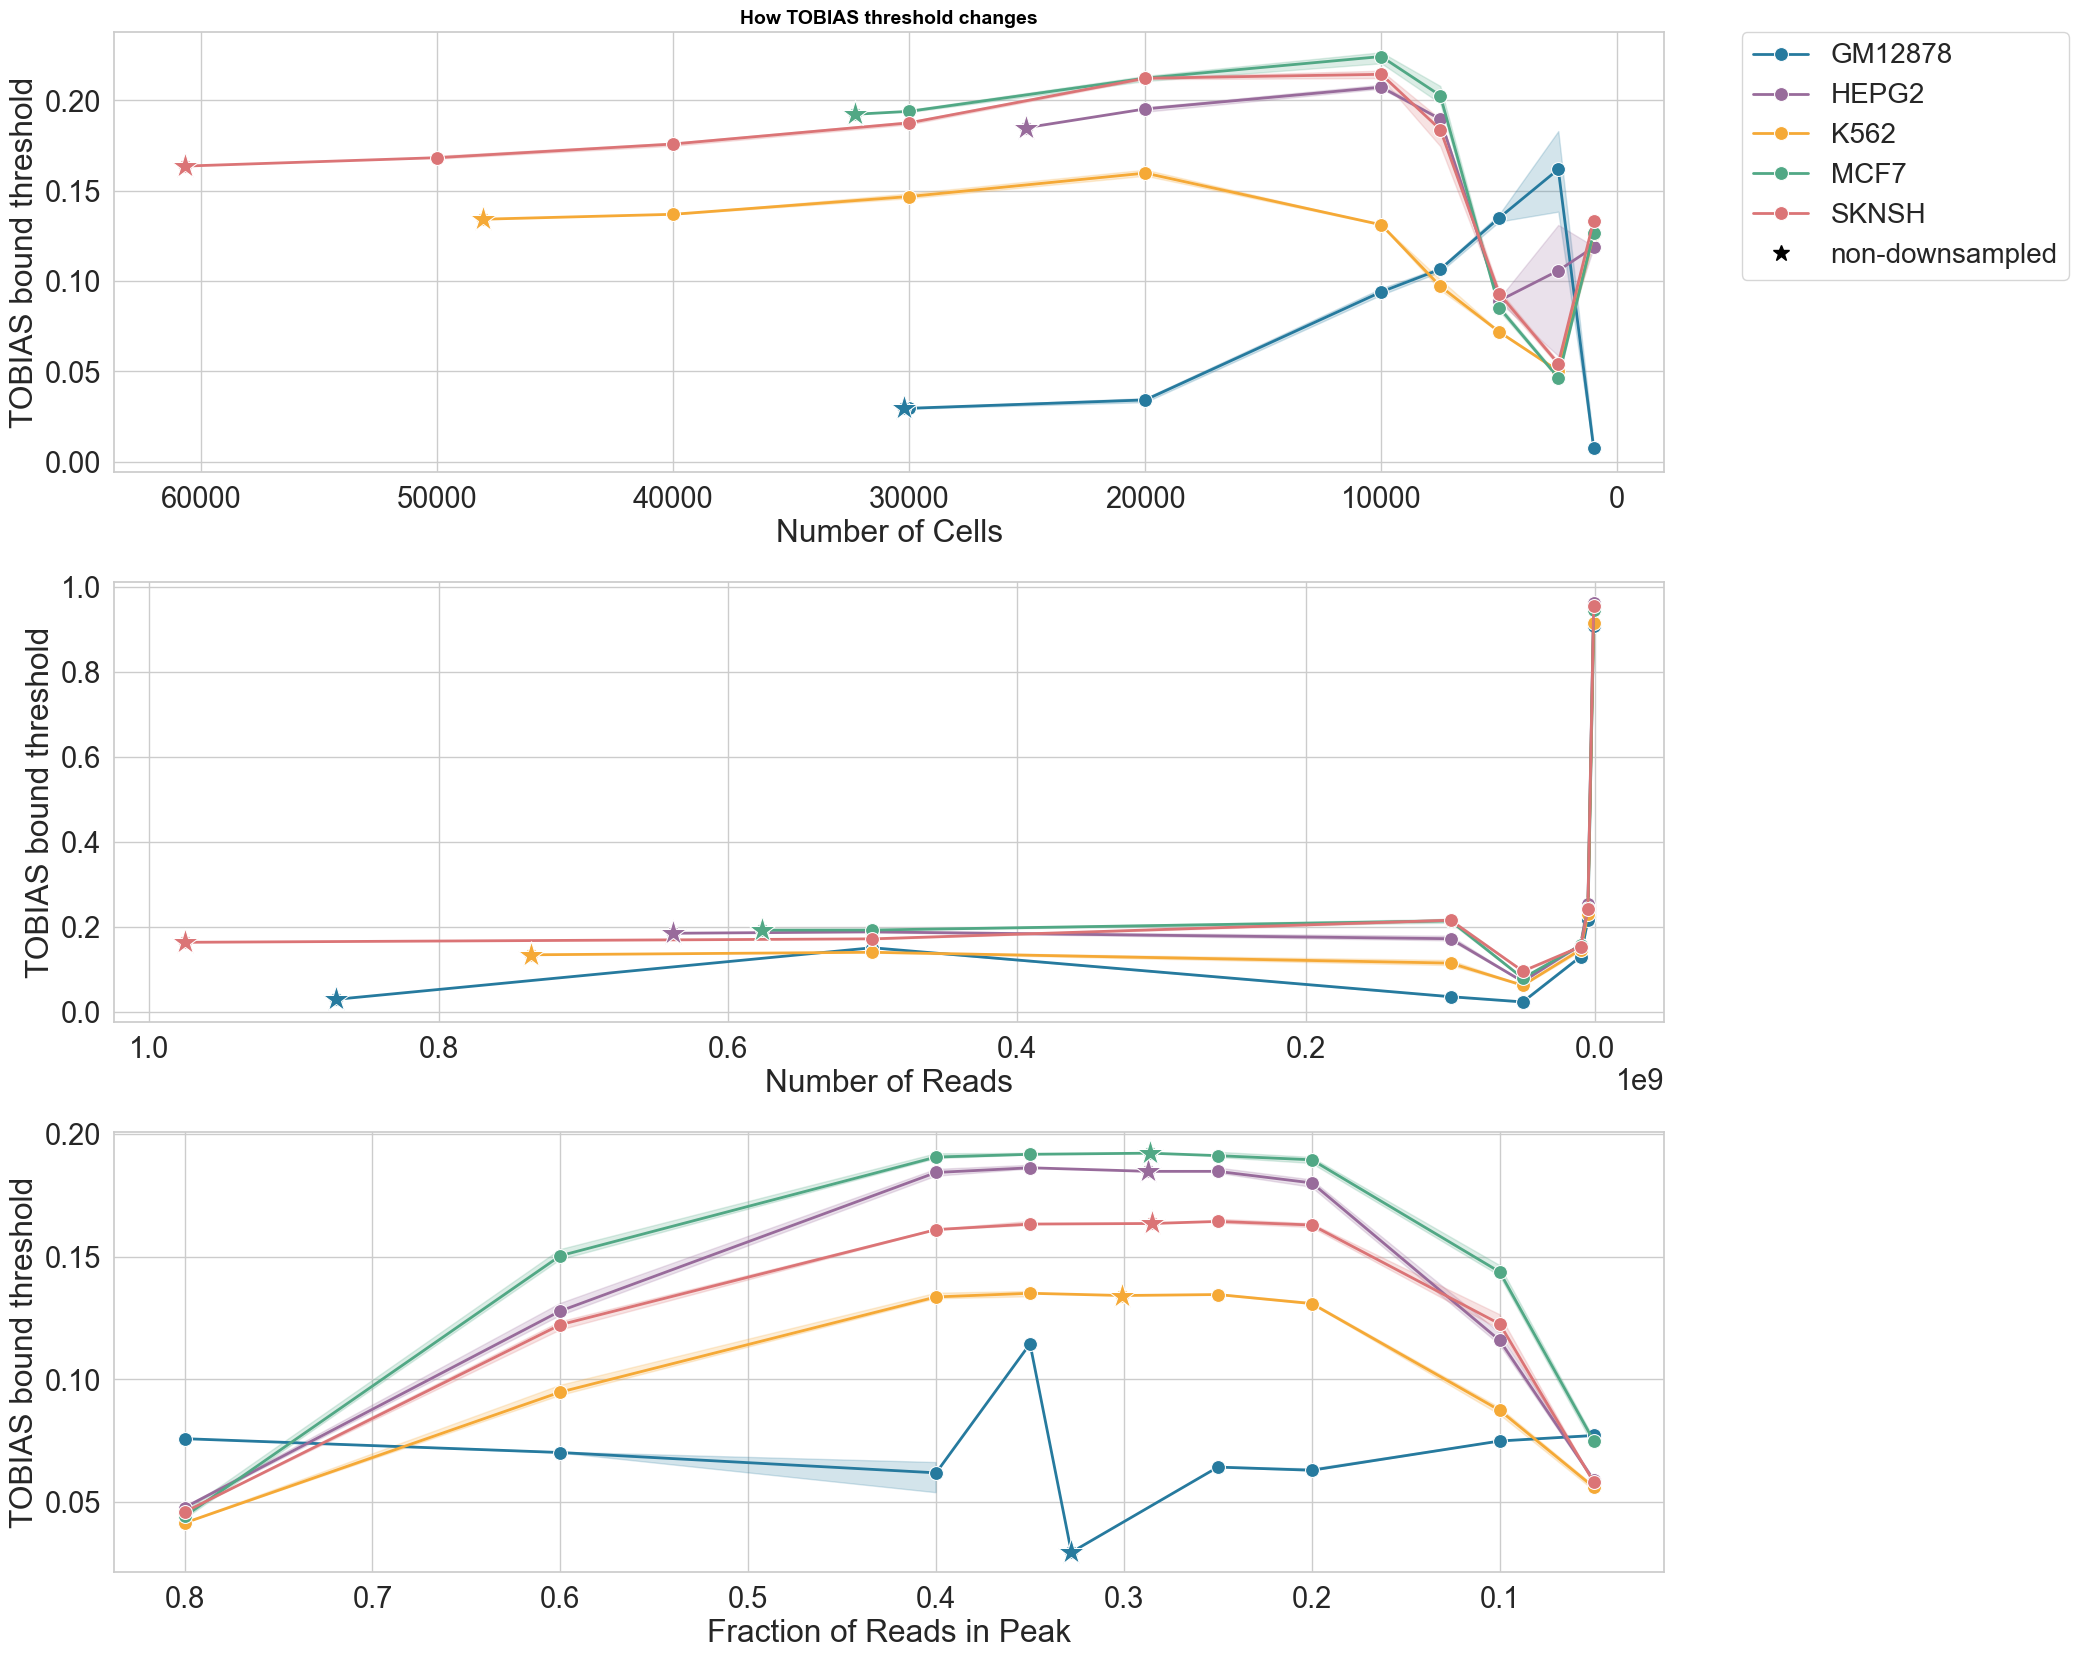

In [87]:
sns.set(font_scale=1.9, style='whitegrid')
fig = plt.figure(figsize=(20, 20))
gs = GridSpec(3, 1, figure=fig, wspace=0.25, hspace=0.25)

ax = fig.add_subplot(gs[0])
tmp = thresh_df[thresh_df.group=="c"].copy()
g = sns.lineplot(data=tmp, 
                 x="value", y="threshold", hue="cell_line",
                 marker="o", linewidth=2, ax=ax, markersize=10, palette=color_scheme_cl)
g = sns.lineplot(data=tmp[tmp.type=="baseline"], 
                 x="value", y="threshold", hue="cell_line",
                 marker="*", ax=ax, markersize=20, palette=color_scheme_cl, legend=False)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
ax.invert_xaxis()
ax.set_xlabel("Number of Cells")
ax.set_ylabel("TOBIAS bound threshold")
ax.set_title("How TOBIAS threshold changes", fontsize=14, color='black', weight='bold')

handles, labels = ax.get_legend_handles_labels() 
star_legend = Line2D([0], [0], color='black', marker='*', linestyle='None', markersize=12)
handles.append(star_legend)
labels.append('non-downsampled')
ax.legend(handles=handles, labels=labels,bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, prop={"size":20})


ax = fig.add_subplot(gs[1])
tmp = thresh_df[thresh_df.group=="r"].copy()
g = sns.lineplot(data=tmp, 
                 x="value", y="threshold", hue="cell_line",
                 marker="o", linewidth=2, ax=ax, markersize=10, palette=color_scheme_cl)
g = sns.lineplot(data=tmp[tmp.type=="baseline"], 
                 x="value", y="threshold", hue="cell_line",
                 marker="*", ax=ax, markersize=20, palette=color_scheme_cl, legend=False)
ax.invert_xaxis()
ax.set_xlabel("Number of Reads")
ax.set_ylabel("TOBIAS bound threshold")
ax.get_legend().remove()


ax = fig.add_subplot(gs[2])
tmp = thresh_df[thresh_df.group=="f"].copy()
g = sns.lineplot(data=tmp, 
                 x="value", y="threshold", hue="cell_line",
                 marker="o", linewidth=2, ax=ax, markersize=10, palette=color_scheme_cl)
g = sns.lineplot(data=tmp[tmp.type=="baseline"], 
                 x="value", y="threshold", hue="cell_line",
                 marker="*", ax=ax, markersize=20, palette=color_scheme_cl, legend=False)
ax.invert_xaxis()
ax.set_xlabel("Fraction of Reads in Peak")
ax.set_ylabel("TOBIAS bound threshold")
ax.get_legend().remove()

plt.show()

## 2.2 Jaccard of threshold pairs <a class="anchor" id="third2-bullet"></a>

In [88]:
##### MAKE THE MATS WITH DIFFERENT THRESHOLD LIMITS ##### 

def _process_chunk(args):
    cl, tool, all_tfs = args
    
    core_dir = "../06_dataquality/"
    out_dir = "../08_acrosstools/mats_by_score/"
    peak_file = f"../03_peakcalls/{cl}_filt_500bp.exclusion.bed.gz"
    
    df = pd.read_csv(f"{peak_file}", header=None, sep="\t")
    df["region_atac"] = df[0].astype(str) + ":" + df[1].astype(str) + "-" + df[2].astype(str)
    all_atac_regions = df["region_atac"].tolist()
    
    df = pd.read_csv(f"{core_dir}/{tool}/cleaned/{cl}-cellFilt.bed.gz", sep="\t")
    if tool == "hint": df["score"] = df["tag_count"]
    thresholds = np.quantile(df["score"], np.linspace(0,1,11))

    for t in thresholds:
        sub = df[df["score"] >= t]
        df_observed = sub.pivot_table(index="region_atac", columns="motif", aggfunc='size', fill_value=0)
        df_observed = df_observed.reindex(all_tfs, axis=1, fill_value=0)
        df_observed = df_observed.reindex(all_atac_regions, axis=0, fill_value=0)
        
        if sub.shape[0] == df_observed.sum().sum():
            df_observed.to_csv(f"{out_dir}/{tool}/{cl}_{round(t,4)}.mat", index=True)
        else:
            print(f"ERRORRRRR: {cl}: {t}")
    return


def main():
    from multiprocessing import Pool

    infile="../05_footprinting/program_input_files/jaspar2022_motifs_to_clusters.txt.gz"
    TF_df = pd.read_csv(infile, sep=" ", header=None, usecols = [0], names=["motif"])
    TF_df["motif"] = [i.upper() for i in TF_df["motif"]] 
    all_tfs = TF_df["motif"].tolist()

    cell_lines = ["HEPG2", "K562", "MCF7", "SKNSH"]
    tools = ["hint", "tobias", "print"]

    tasks = [(cl, tool, all_tfs) for cl in cell_lines for tool in tools]

    with Pool(processes=12) as pool: 
        pool.map(_process_chunk, tasks)

    print("done")
    
#main()

In [89]:
##### CALCULATE METRICS FOR ALL PAIRWISE COMBINATIONS ##### 

def _calculate_jaccard(df):
    df["min"] = df.min(axis=1)
    u = df[["df1","df2"]].sum().sum()
    i = df["min"].sum()
    return i/u, (i/df["df1"].sum()*100), (i/df["df2"].sum()*100)

def _gather_metrics(df1, df2):
    data = {
    'df1': df1.to_numpy().flatten(),
    'df2': df2.to_numpy().flatten()
    }
    df = pd.DataFrame(data)
    df_nonZero = df.loc[~(df==0).all(axis=1)]
    df_nonZero.reset_index(drop=True, inplace=True)

    a,b,c = _calculate_jaccard(df_nonZero.copy())
    vals = [pearsonr(df_nonZero["df1"], df_nonZero["df2"])[0],
            spearmanr(df_nonZero["df1"], df_nonZero["df2"])[0],
            mean_squared_error(df_nonZero["df1"], df_nonZero["df2"]),
            a,b,c]
    
    return vals

def process_chunk(args):
    i, j, tool1, tool2 = args
    
    core_dir = "../08_acrosstools/mats_by_score/"
    df1 = pd.read_csv(f"{core_dir}/{tool1}/{i}", index_col=0)
    df2 = pd.read_csv(f"{core_dir}/{tool2}/{j}", index_col=0)
    totalA = df1.sum().sum()
    totalB = df2.sum().sum()
    info = [tool1, tool2, 
            re.sub(".mat", "", i.split("_")[1]), re.sub(".mat", "", j.split("_")[1]),
            totalA, totalB]
    
    if (totalA == 0) | (totalB == 0):
        info2 = [np.nan]*6
    else:
        info2 = _gather_metrics(df1, df2)
    return info + info2


def main():
    for cl in ["HEPG2"]:
        core_dir = "../08_acrosstools/mats_by_score/"
        files_hint = [x for x in os.listdir(f"{core_dir}/hint/") if cl in x ]
        files_tobias = [x for x in os.listdir(f"{core_dir}/tobias/") if cl in x ]
        files_print = [x for x in os.listdir(f"{core_dir}/print/") if cl in x ]

        combinations = list([i + ("hint", "tobias") for i in product(files_hint, files_tobias)] +
                            [i + ("hint", "print") for i in product(files_hint, files_print)] +
                            [i + ("tobias", "print") for i in product(files_tobias, files_print)])

        with Pool(processes=12) as pool:  
            results = pool.map(process_chunk, combinations)

    output_df = pd.DataFrame(results, columns=['tool1', 'tool2', 'thresh1', 'thresh2', "NumTFBS_a", "NumTFBS_b",
                                                'pearsonr', "spearmanr", "mse", "jaccard", "%a", "%b"])

    output_df.to_csv(f"{core_dir}/{cl}_decile_metrics.csv", index=False)
    print("done")
    
#main()

In [90]:
core_dir = "../../08_acrosstools/"
df = pd.read_csv(f"{core_dir}/HEPG2_decile_metrics.csv.gz")
#new users will need to make this file. 

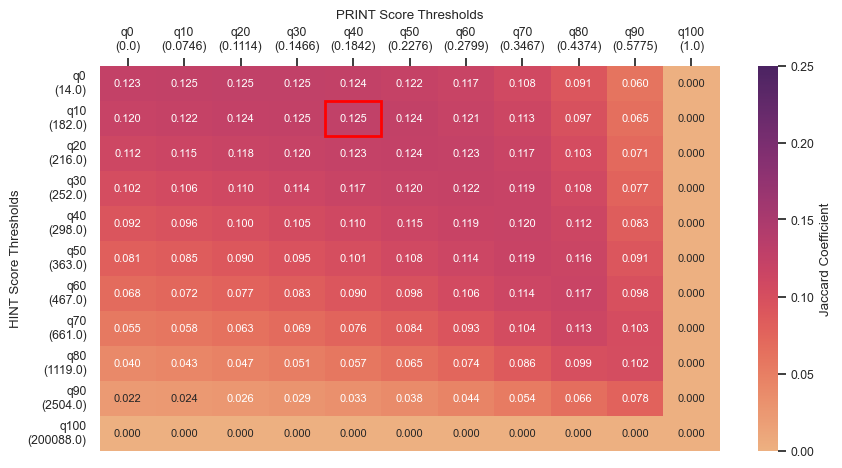

In [91]:
sns.set(font_scale=0.8, style='whitegrid')
fig = plt.figure(figsize=(10,5))
gs = GridSpec(1, 1, figure=fig, wspace=0.25, hspace=0.45)

ax = fig.add_subplot(gs[0])
a = "hint"
b = "print"
tmp = df[(df.tool1==a) & (df.tool2==b)]
v = "jaccard"
pivot_tmp = tmp.pivot_table(index='thresh1', columns='thresh2', values=v)
pivot_tmp.columns = [f"q{round(i*100)}\n({j})" for i,j in zip(np.linspace(0,1,11), pivot_tmp.columns)]
pivot_tmp.index = [f"q{round(i*100)}\n({j})" for i,j in zip(np.linspace(0,1,11), pivot_tmp.index)]

g = sns.heatmap(pivot_tmp,
            annot=True, fmt=".3f", cmap="flare",
            annot_kws={"size":8}, vmin=0, vmax=0.25, cbar=True)
cbar = g.collections[0].colorbar
cbar.set_label("Jaccard Coefficient")

max_row, max_col = pivot_tmp.values.argmax() // pivot_tmp.shape[1], pivot_tmp.values.argmax() % pivot_tmp.shape[1]
plt.gca().add_patch(plt.Rectangle((max_col, max_row), 1, 1, fill=False, edgecolor='red', lw=2))

ax.xaxis.tick_top()
ax.set_ylabel(f"{a.upper()} Score Thresholds")
ax.set_title(f"{b.upper()} Score Thresholds")

plt.show()

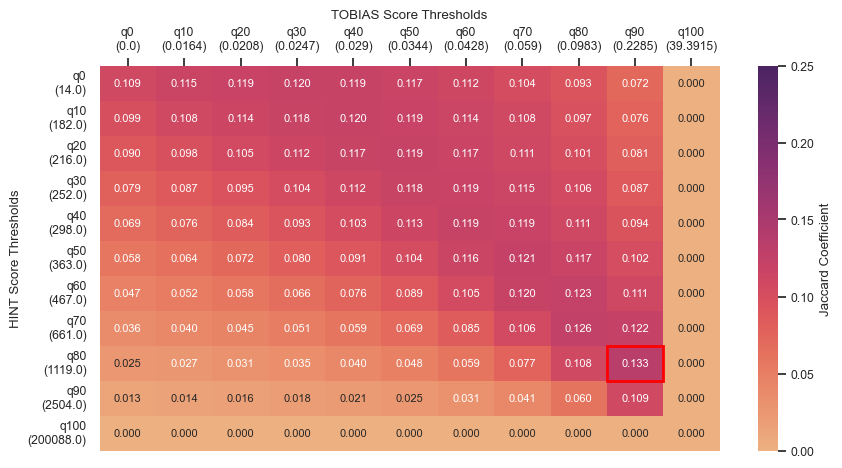

In [92]:
sns.set(font_scale=0.8, style='whitegrid')
fig = plt.figure(figsize=(10,5))
gs = GridSpec(1, 1, figure=fig, wspace=0.25, hspace=0.45)

ax = fig.add_subplot(gs[0])
a = "hint"
b = "tobias"
tmp = df[(df.tool1==a) & (df.tool2==b)]
v = "jaccard"
pivot_tmp = tmp.pivot_table(index='thresh1', columns='thresh2', values=v)
pivot_tmp.columns = [f"q{round(i*100)}\n({j})" for i,j in zip(np.linspace(0,1,11), pivot_tmp.columns)]
pivot_tmp.index = [f"q{round(i*100)}\n({j})" for i,j in zip(np.linspace(0,1,11), pivot_tmp.index)]

g = sns.heatmap(pivot_tmp,
            annot=True, fmt=".3f", cmap="flare",
            annot_kws={"size":8}, vmin=0, vmax=0.25, cbar=True)
cbar = g.collections[0].colorbar
cbar.set_label("Jaccard Coefficient")

max_row, max_col = pivot_tmp.values.argmax() // pivot_tmp.shape[1], pivot_tmp.values.argmax() % pivot_tmp.shape[1]
plt.gca().add_patch(plt.Rectangle((max_col, max_row), 1, 1, fill=False, edgecolor='red', lw=2))

ax.xaxis.tick_top()
ax.set_ylabel(f"{a.upper()} Score Thresholds")
ax.set_title(f"{b.upper()} Score Thresholds")
plt.show()

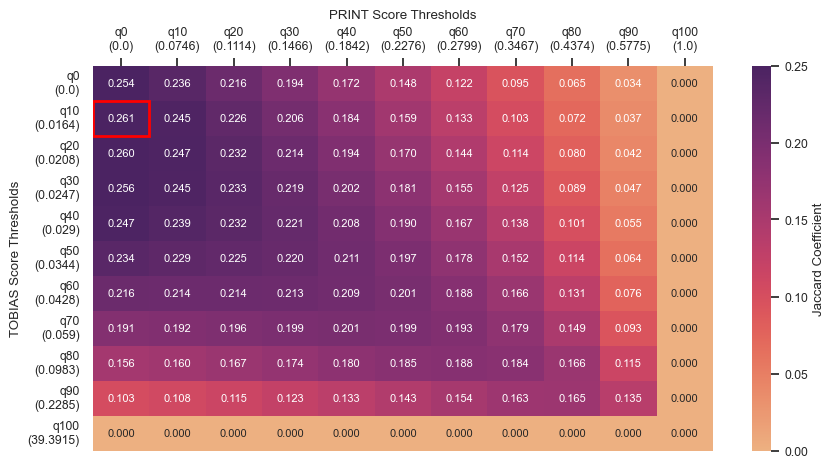

In [93]:
sns.set(font_scale=0.8, style='whitegrid')
fig = plt.figure(figsize=(10,5))
gs = GridSpec(1, 1, figure=fig, wspace=0.25, hspace=0.45)

ax = fig.add_subplot(gs[0])
a = "tobias"
b = "print"
tmp = df[(df.tool1==a) & (df.tool2==b)]
v = "jaccard"
pivot_tmp = tmp.pivot_table(index='thresh1', columns='thresh2', values=v)
pivot_tmp.columns = [f"q{round(i*100)}\n({j})" for i,j in zip(np.linspace(0,1,11), pivot_tmp.columns)]
pivot_tmp.index = [f"q{round(i*100)}\n({j})" for i,j in zip(np.linspace(0,1,11), pivot_tmp.index)]

g = sns.heatmap(pivot_tmp,
            annot=True, fmt=".3f", cmap="flare",
            annot_kws={"size":8}, vmin=0, vmax=0.25, cbar=True)
cbar = g.collections[0].colorbar
cbar.set_label("Jaccard Coefficient")

max_row, max_col = pivot_tmp.values.argmax() // pivot_tmp.shape[1], pivot_tmp.values.argmax() % pivot_tmp.shape[1]
plt.gca().add_patch(plt.Rectangle((max_col, max_row), 1, 1, fill=False, edgecolor='red', lw=2))

ax.xaxis.tick_top()
ax.set_ylabel(f"{a.upper()} Score Thresholds")
ax.set_title(f"{b.upper()} Score Thresholds")

plt.show()

# 4. Genome-wide trends <a class="anchor" id="fourth-bullet"></a>

In [94]:
def _get_cellline_arrays(cl):
    peak_file = f"../03_peakcalls/{cl}_filt_500bp.exclusion.bed.gz"
    df = pd.read_csv(f"{peak_file}", header=None, sep="\t")
    df["region_atac"] = df[0].astype(str) + ":" + df[1].astype(str) + "-" + df[2].astype(str)
    all_atac_regions = df["region_atac"].tolist()
    
    return all_atac_regions

    
def _addHINTdenovo(cl):
    peak_file = f"../03_peakcalls/{cl}_filt_500bp.exclusion.bed.gz"
    foot_file = f"../../05_footprinting/01_original/hint/{cl}-cellFilt.bed"
    tmp_file = f"current_hint_{random.randint(1, 1000)}.bed" #bc multiprocessing
    
    ! bedtools intersect \
        -a {peak_file} \
        -b <(awk '{{sub(/[ \t]+$$/, ""); print}}' {foot_file}) \
        -F 0.5 -wb -wa -sorted > {tmp_file}

    tmp = pd.read_csv(tmp_file, header=None, sep="\t")
    tmp["region_atac"] = tmp[0].astype(str) + ":" + tmp[1].astype(str) + "-" + tmp[2].astype(str)
    all_atac_regions = _get_cellline_arrays(cl)
    
    if len(set(tmp["region_atac"]) - set(all_atac_regions)) != 0:
        print("uh oh"); return
    else:
        ! rm {tmp_file}
    
    value_counts_df = (
        tmp["region_atac"]
        .value_counts()
        .reindex(all_atac_regions, fill_value=0)  # Reindex with the external vector, filling missing values with 0
        .reset_index()  # Reset index to make it a proper dataframe
    )

    value_counts_df.columns = ['region_atac', '#footprints']
    value_counts_df["tool"] = "hint-denovo"
    value_counts_df["cell_line"] = cl
    return value_counts_df[['region_atac', '#footprints', 'tool',  'cell_line']]


def _addPRINTdenovo(cl):
    peak_file = f"../03_peakcalls/{cl}_filt_500bp.exclusion.bed.gz"
    foot_file = f"../../05_footprinting/01_original/print/{cl}/{cl}_denovo_granges.bed"
    tmp_file = f"current_print_{random.randint(1, 1000)}.bed" #bc multiprocessing
    
    ! bedtools intersect \
        -a {peak_file} \
        -b <(tail -n+2 {foot_file} | tr " " "\t" | sort -k1,1 -k2,2n) \
        -F 0.5 -wb -wa -sorted > {tmp_file}

    #read in df and merge by tag count. 
    df = pd.read_csv(tmp_file, sep="\t", header=None) 
    df = df.drop_duplicates()
    df["region_atac"] = df[0].astype(str) + ":" + df[1].astype(str) + "-" + df[2].astype(str)
    df["region_TFBS"] = df[6].astype(str) + ":" + df[7].astype(str) + "-" + df[8].astype(str)
    df["score"] = df[13]
    df = df[df["score"] >= 0.3]
    
    all_atac_regions = _get_cellline_arrays(cl)

    if len(set(df["region_atac"]) - set(all_atac_regions)) != 0:
        print("uh oh"); return
    else:
        ! rm {tmp_file}
        
    value_counts_df = (
        df["region_atac"]
        .value_counts()
        .reindex(all_atac_regions, fill_value=0)  # Reindex with the external vector, filling missing values with 0
        .reset_index()  # Reset index to make it a proper dataframe
    )

    value_counts_df.columns = ['region_atac', '#footprints']
    value_counts_df["tool"] = "print-denovo"
    value_counts_df["cell_line"] = cl
    return value_counts_df[['region_atac', '#footprints', 'tool',  'cell_line']]




def _process_chunk(args):
    cl, tool = args
    core_dir = "../../06_dataquality/"

    tmp = pd.read_csv(f"{core_dir}/{tool}/mats/{cl}-cellFilt.mat", index_col=0)
    pwm = tmp.sum(axis=0)
    peak = tmp.sum(axis=1)

    pwm_df = pwm.to_frame(name="#footprints").reset_index().rename(columns={"index": "TF"})
    pwm_df["tool"] = tool
    pwm_df["cell_line"] = cl

    peak_df = peak.to_frame(name="#footprints").reset_index().rename(columns={"index": "peak"})
    peak_df["tool"] = tool
    peak_df["cell_line"] = cl
    
    return pwm_df, peak_df

    
def run_parallel(func, args, processes):
    with Pool(processes=processes) as pool:
        return pool.map(func, args)


def main():
    cell_lines = ["HEPG2", "K562", "MCF7", "SKNSH"]
    tools = ["hint", "print", "tobias",  "pwm"]
    
    tasks = [(cl, tool) for cl in cell_lines for tool in tools]
    results = run_parallel(_process_chunk, tasks, processes=12)
    byPWM, byPeak = zip(*results)
    
    byPeak = list(byPeak)
    byPeak += run_parallel(_addHINTdenovo, cell_lines, processes=4) 
    byPeak += run_parallel(_addPRINTdenovo, cell_lines, processes=4)
    
    PEAKdf = pd.concat(byPeak, ignore_index=True)
    PWMdf = pd.concat(byPWM, ignore_index=True)
    
    PEAKdf.to_csv('baseline_peakdf.csv')  
    PWMdf.to_csv('baseline_pwmdf.csv')  
    print("done")

from multiprocessing import Pool
import random

#main()

In [95]:
genome_wide_PWM = pd.read_csv("baseline_pwmdf.csv.gz", index_col=0)
genome_wide_Peak = pd.read_csv("baseline_peakdf.csv.gz", index_col=0) #new users will need to make this using code above. 
genome_wide = pd.DataFrame(genome_wide_Peak.groupby(["tool", "cell_line"])["#footprints"].sum()).reset_index()
display(genome_wide_PWM)

,TF,#footprints,tool,cell_line
0,BATF::JUN_MA0462.2,13253,hint,HEPG2
1,BATF_MA1634.1,13409,hint,HEPG2
2,FOSB::JUNB_MA1135.1,15636,hint,HEPG2
3,FOSL2::JUNB_MA1138.1,15616,hint,HEPG2
4,FOSL2::JUND_MA1144.1,15660,hint,HEPG2
...,...,...,...,...
13451,ZSCAN31_MA1722.1,5085,pwm,SKNSH
13452,REST_MA0138.2,50388,pwm,SKNSH
13453,RREB1_MA0073.1,552041,pwm,SKNSH
13454,THRB_MA1575.1,76195,pwm,SKNSH


In [96]:
pwm_values = genome_wide_PWM[genome_wide_PWM["tool"] == "pwm"].set_index(["TF", "cell_line"])["#footprints"]
genome_wide_PWM["pwm_ref"] = genome_wide_PWM.set_index(["TF", "cell_line"]).index.map(pwm_values)
genome_wide_PWM["pct_occupied"] = (genome_wide_PWM["#footprints"] / genome_wide_PWM["pwm_ref"]) * 100

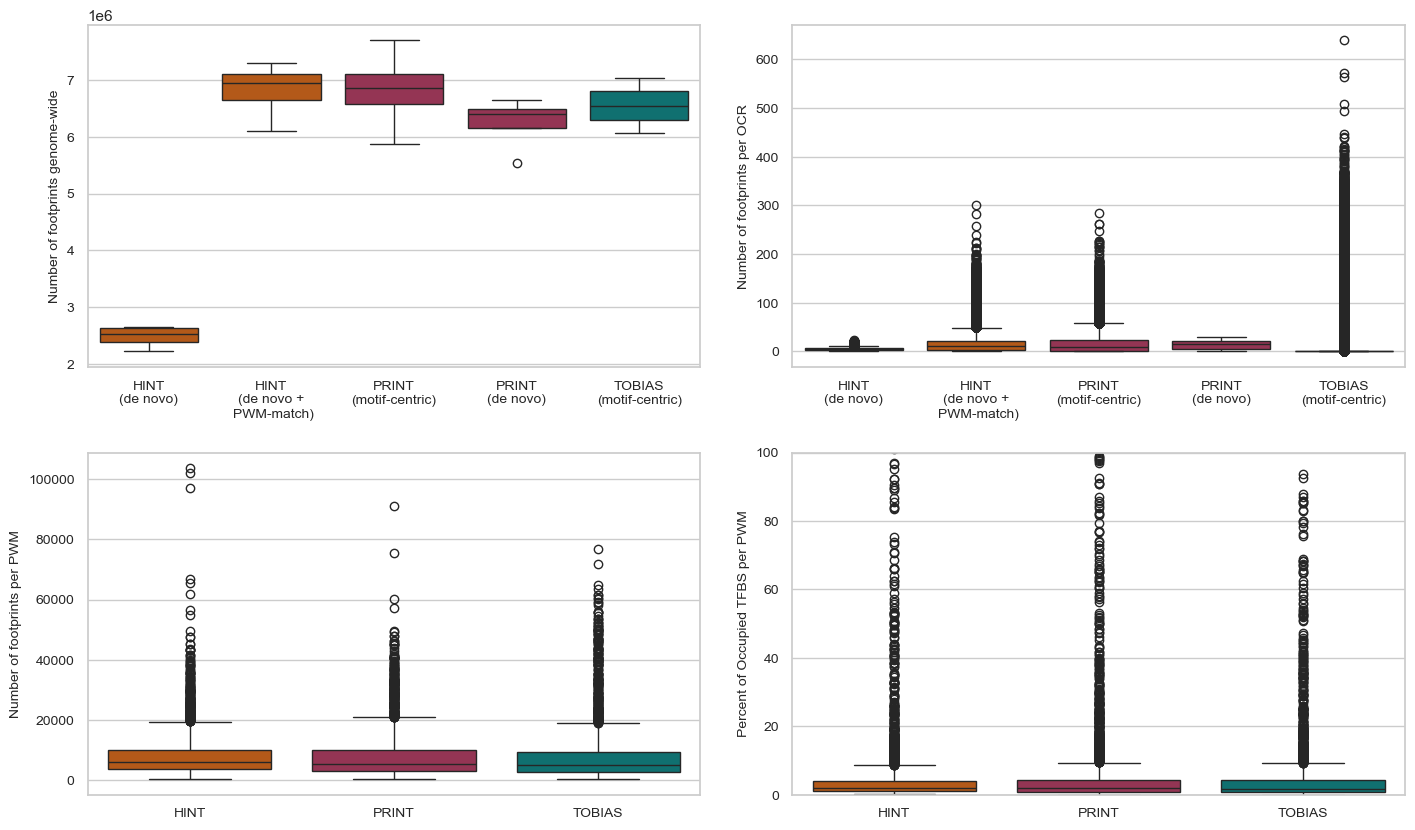

In [97]:
color_scheme_prog = {'tobias': '#008080', 'hint': '#CC5500', 'print': '#A4254E', 'pwm':"grey",
                     'hint-denovo': '#CC5500', 'print-denovo': '#A4254E'}

sns.set(font_scale=1, style='whitegrid')
fig = plt.figure(figsize=(17,10))
gs = GridSpec(2, 2, figure=fig, wspace=0.15, hspace=0.25)

order = ["hint-denovo", "hint",  "print", "print-denovo", "tobias"]
ax0 = fig.add_subplot(gs[0])
sns.boxplot(genome_wide[genome_wide.tool != "pwm"], 
            y="#footprints", x="tool", 
            palette=color_scheme_prog, 
            ax = ax0, order=order)

ax1 = fig.add_subplot(gs[1])
sns.boxplot(genome_wide_Peak[genome_wide_Peak.tool != "pwm"], 
            y="#footprints", x="tool",
            palette=color_scheme_prog, 
            ax = ax1, order=order)

order = ["hint", "print", "tobias"]
ax2 = fig.add_subplot(gs[2])
sns.boxplot(genome_wide_PWM[genome_wide_PWM.tool != "pwm"], 
            y="#footprints", x="tool", 
            palette=color_scheme_prog, 
            ax = ax2, order=order)

ax3 = fig.add_subplot(gs[3])
sns.boxplot(genome_wide_PWM[genome_wide_PWM.tool != "pwm"], 
            y="pct_occupied", x="tool", 
            palette=color_scheme_prog, 
            ax = ax3, order=order)


ax0.set_ylabel("Number of footprints genome-wide", fontsize=10)
ax1.set_ylabel("Number of footprints per OCR", fontsize=10)
ax2.set_ylabel("Number of footprints per PWM", fontsize=10)
ax3.set_ylabel("Percent of Occupied TFBS per PWM", fontsize=10)

prettylabels = ['HINT\n(de novo)', 'HINT\n(de novo +\n PWM-match)', 'PRINT\n(motif-centric)', 'PRINT\n(de novo)', 'TOBIAS\n(motif-centric)']
ax0.set_xticks(ax0.get_xticks()); ax0.set_xticklabels(prettylabels, fontsize=10)#, rotation=25, ha='right')
ax1.set_xticks(ax1.get_xticks()); ax1.set_xticklabels(prettylabels, fontsize=10)#, rotation=25, ha='right')
prettylabels = ["HINT", "PRINT", "TOBIAS"]
ax2.set_xticks(ax2.get_xticks()); ax2.set_xticklabels(prettylabels, fontsize=10)#, rotation=25, ha='right')
ax3.set_xticks(ax3.get_xticks()); ax3.set_xticklabels(prettylabels, fontsize=10)#, rotation=25, ha='right')

ax0.tick_params(labelsize=10)
ax1.tick_params(labelsize=10)
ax2.tick_params(labelsize=10)
ax3.tick_params(labelsize=10)

ax0.set_xlabel("")
ax1.set_xlabel("")
ax2.set_xlabel("")
ax3.set_xlabel("")

ax3.set_ylim(0,100)

plt.show()

# 5. Similarity of TF rankings <a class="anchor" id="fifth-bullet"></a>

In [98]:
def _KT_AcrossTools(df, 
                    cell_lines = ["HEPG2", "MCF7", "K562", "SKNSH"], 
                    tools = ["pwm", "hint","tobias", "print"], 
                    rankby="#footprints"):
    
    from scipy.stats import kendalltau, weightedtau
    
    results=list()
    for cl in cell_lines:
        for t1, t2 in list(combinations(tools, 2)):
            sorted_motifs_list1=df.loc[(df.cell_line == cl) & (df.tool==t1)].sort_values(by=rankby, ascending=False).index
            sorted_motifs_list2=df.loc[(df.cell_line == cl) & (df.tool==t2)].sort_values(by=rankby, ascending=False).index
            
            rank_map = {char: rank for rank, char in enumerate(sorted_motifs_list1)}
            ranked_motifs_list1 = [rank_map[char] for char in sorted_motifs_list1]
            ranked_motifs_list2 = [rank_map[char] for char in sorted_motifs_list2]

            kt_cor, pval = kendalltau(ranked_motifs_list1, ranked_motifs_list2) #identical to weightedtau(ranked_list1, ranked_list2, weigher=lambda x: 1)
            wkt_cor = weightedtau(ranked_motifs_list1, ranked_motifs_list2)
            results.append([cl, t1, t2, kt_cor, wkt_cor.statistic])

    tau_df = pd.DataFrame(results, columns = ['CellLine', 'tool1', 'tool2', 'kendall_tau', 'kendall_tau_weighted']) 
    tau_df["tools"] = tau_df["tool1"] + ":" + tau_df["tool2"]
    return tau_df


def _formatEnrichment(value_column = '# of Target Sequences with Motif'):
    allcolnames = ['Motif Name', 'Consensus', 'P-value', 'Log P-value',
                   'q-value (Benjamini)', '# of Target Sequences with Motif',
                   '% of Target Sequences with Motif',
                   '# of Background Sequences with Motif',
                   '% of Background Sequences with Motif', 
                   "NumForegroundSeq", "NumBackgroundSeq"]
    
    df_list = list()
    for cl in ["HEPG2", "MCF7", "K562", "SKNSH"]:
        df = pd.read_table(f"motif_enrichment/{cl}/knownResults.txt")
        
        match = re.search(r"\(of (\d+)\)", df.columns[5])
        df["NumForegroundSeq"] = int(match.group(1))
        
        match = re.search(r"\(of (\d+)\)", df.columns[7])
        df["NumBackgroundSeq"] = int(match.group(1))
        
        df.columns = allcolnames
        df["cell_line"] = cl    
        df_list.append(df)
    
        
    df = pd.concat(df_list)
    df['% of Target Sequences with Motif'] = [i[:-1] for i in df['% of Target Sequences with Motif']]
    df['% of Background Sequences with Motif'] = [i[:-1] for i in df['% of Background Sequences with Motif']]
    
    num_cols = ['P-value', 'Log P-value',
           'q-value (Benjamini)', '# of Target Sequences with Motif',
           '% of Target Sequences with Motif',
           '# of Background Sequences with Motif',
           '% of Background Sequences with Motif', 'NumForegroundSeq',
           'NumBackgroundSeq']
    
    df[num_cols] = df[num_cols].apply(pd.to_numeric)
    
    df[['motif', 'TF']] = df["Motif Name"].str.split(':::', expand=True)
    df['motif'] = df['motif'].str.upper()
    df['TF'] = df['TF'].str.upper()
    df["motif_name"] = df["TF"] + "_" + df["motif"]
    df["tool"] = "homer"
    
    if value_column == 'Log P-value':
        df["value"] = 1 - df['Log P-value']
        value_column = "value"
        
    tmp = df[["motif_name", "cell_line", "tool",  value_column]].copy()
    tmp.columns = ["motif", "cell_line", "tool",  "value"]
    return tmp

#'# of Target Sequences with Motif'  low=bad so ascending = False
#'P-value'  low=good so ascending = True
# why you added a 1- flag in the code above. 

In [99]:
#Get program info. set #footprints as value of interest. 
genome_wide_PWM = pd.read_csv("baseline_pwmdf.csv.gz", index_col=0)
genome_wide_PWM.columns = ["motif", "value", "tool", "cell_line"]

#can also do this by the pct of occupied sites 
# pwm_values = genome_wide_PWM[genome_wide_PWM["tool"] == "pwm"].set_index(["TF", "cell_line"])["#footprints"]
# genome_wide_PWM["pwm_ref"] = genome_wide_PWM.set_index(["TF", "cell_line"]).index.map(pwm_values)
# genome_wide_PWM["pct_occupied"] = (genome_wide_PWM["#footprints"] / genome_wide_PWM["pwm_ref"]) * 100

#add motif enrichment scores
df = _formatEnrichment(value_column = 'Log P-value')

final_df = pd.concat([df, genome_wide_PWM], axis=0)

#create random shuffle of value
final_df['value_shuffled'] = (
    final_df.groupby(["tool", "cell_line"])['value']
      .transform(lambda x: np.random.permutation(x.values))
)

final_df.index = final_df.motif
display(final_df)

,motif,cell_line,tool,value,value_shuffled
motif,,,,,
CTCF_MA0139.1,CTCF_MA0139.1,HEPG2,homer,23811.0,4.331
CTCF_MA1929.1,CTCF_MA1929.1,HEPG2,homer,9896.0,47.610
CTCF_MA1930.1,CTCF_MA1930.1,HEPG2,homer,8987.0,222.600
FOS::JUND_MA1141.1,FOS::JUND_MA1141.1,HEPG2,homer,4819.0,13.840
FOS::JUNB_MA1134.1,FOS::JUNB_MA1134.1,HEPG2,homer,4789.0,90.020
...,...,...,...,...,...
ZSCAN31_MA1722.1,ZSCAN31_MA1722.1,SKNSH,pwm,5085.0,290427.000
REST_MA0138.2,REST_MA0138.2,SKNSH,pwm,50388.0,370846.000
RREB1_MA0073.1,RREB1_MA0073.1,SKNSH,pwm,552041.0,18890.000


In [100]:
tmp1 = _KT_AcrossTools(final_df, 
                       tools = ["pwm", "hint","tobias", "print", "homer"],
                       rankby="value")
tmp1["comparison"] = "Metric"

tmp2 = _KT_AcrossTools(final_df, 
                       tools = ["pwm", "hint","tobias", "print", "homer"],
                       rankby="value_shuffled")
tmp2["comparison"] = "Metric: Shuffled"

tau_df = pd.concat([tmp1, tmp2])
tau_df_grouped = pd.DataFrame({'mean' : tau_df.groupby(["tools", "comparison"])['kendall_tau_weighted'].mean(),
                               'sd'   : tau_df.groupby(["tools", "comparison"])['kendall_tau_weighted'].std()}).reset_index()
tau_df_grouped["labels"] = tau_df_grouped.apply(lambda row: f"{row['mean']:.2f} ± {row['sd']:.2f}", axis=1)

display(tau_df_grouped)


,tools,comparison,mean,sd,labels
0,hint:homer,Metric,0.275635,0.135178,0.28 ± 0.14
1,hint:homer,Metric: Shuffled,-0.012851,0.042521,-0.01 ± 0.04
2,hint:print,Metric,0.868963,0.020261,0.87 ± 0.02
3,hint:print,Metric: Shuffled,-0.015555,0.016701,-0.02 ± 0.02
4,hint:tobias,Metric,0.795347,0.031558,0.80 ± 0.03
5,hint:tobias,Metric: Shuffled,-0.055163,0.100635,-0.06 ± 0.10
6,print:homer,Metric,0.359612,0.101764,0.36 ± 0.10
7,print:homer,Metric: Shuffled,0.034110,0.055794,0.03 ± 0.06
8,pwm:hint,Metric,0.509431,0.023718,0.51 ± 0.02
9,pwm:hint,Metric: Shuffled,-0.021773,0.058633,-0.02 ± 0.06


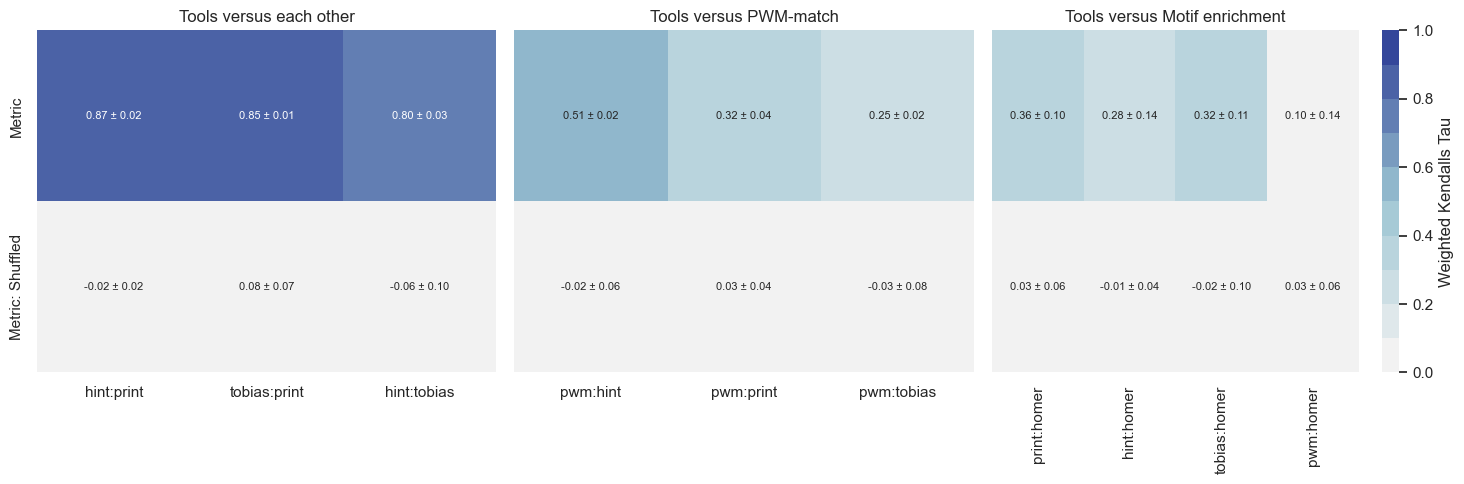

In [101]:
toplot = tau_df_grouped.pivot(index='comparison', columns='tools', values='mean')
labels = tau_df_grouped.pivot(index='comparison', columns='tools', values='labels')

gray_to_blue = LinearSegmentedColormap.from_list("gray_blue", ["#F2F2F2", "#9CC5D2", "#34469A"])
pal = sns.color_palette(gray_to_blue(np.linspace(0, 1, 10)))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns

vals = ['hint:print', 'tobias:print', 'hint:tobias']
sns.heatmap(toplot[vals],
            annot = labels[vals], annot_kws={"size": 8}, fmt='',
            ax=axes[0], 
            cbar=False, cmap=pal,
            vmin=0, vmax=1)
axes[0].set_title('Tools versus each other')
axes[0].set_ylabel(""); axes[0].set_xlabel("")

vals = ['pwm:hint', 'pwm:print', 'pwm:tobias']
sns.heatmap(toplot[vals], 
            annot = labels[vals], annot_kws={"size": 8}, fmt='',
            ax=axes[1], 
            cbar=False, cmap=pal,
            vmin=0, vmax=1)
axes[1].set_title('Tools versus PWM-match')
axes[1].set_ylabel(""); axes[1].set_xlabel("")

vals = ['print:homer', 'hint:homer', 'tobias:homer', 'pwm:homer']
sns.heatmap(toplot[vals], 
            annot = labels[vals], annot_kws={"size": 8}, fmt='',
            ax=axes[2], 
            cbar=True, cmap=pal, cbar_kws={"label": "Weighted Kendalls Tau"},
            vmin=0, vmax=1)
axes[2].set_title('Tools versus Motif enrichment')
axes[2].set_ylabel(""); axes[2].set_xlabel("")

axes[1].set_yticklabels(""); axes[2].set_yticklabels("")
# axes[1].set_ylabel(""); axes[1].set_xlabel("")
# axes[2].set_ylabel(""); axes[2].set_xlabel("")

plt.tight_layout()
plt.show()